# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_4_Feature_Selection

- 입력 데이터: 02_EDA가 저장한 `labeled_modeling.csv`
- 특징 선택 검토 (스크리닝)
- 평가 프로토콜: 80/20 단일 분할 (`random_state=0`), test set 1046건 / 불량 12건
- 주의: 여기 수치는 **후보 비교용**임. 보고 수치는 **04_6 반복 CV 기준** (`ANALYSIS_FLOW.md` 참고)

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

result_df=pd.read_csv('04_3_PCA.csv')

5230행 30컬럼 / 불량 60건


In [4]:
model_data.head()

,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part
0,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.47,16.92,59.520000,...,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5,CN7RH
1,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7RH
2,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7LH
3,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7LH
4,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7RH


In [5]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


## Feature Selection 실험

In [6]:
# Feature Selection 실험 공통 라이브러리
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import make_scorer, precision_score, recall_score, fbeta_score
from sklearn.utils.validation import check_is_fitted
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 공통 평가 함수
from utils.model_evaluation import evaluate_models, show_random_forest_feature_importance

set_config(display='text')

### 데이터 전처리

In [7]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=model_data.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print("데이터 분할 결과")
print(f'X_Train: {x_train.shape}, Y_Train: {y_train.shape}')
print(f'X_Test: {x_test.shape}, Y_Test: {y_test.shape}')
print(f'불량 수 - 전체: {y.sum()}, Train: {y_train.sum()}, Test: {y_test.sum()}')

# 스케일링과 SMOTE는 Pipeline 안에서 각 학습 fold에만 적용

데이터 분할 결과
X_Train: (4184, 26), Y_Train: (4184,)
X_Test: (1046, 26), Y_Test: (1046,)
불량 수 - 전체: 60, Train: 48, Test: 12


### Part 보존 Feature Selector

In [8]:
class PartPreservingFeatureSelector(BaseEstimator, TransformerMixin):
    """공정 변수만 선택하고 Part 더미변수는 항상 보존하는 변환기"""

    def __init__(self, k_process=12, part_prefix='Part_', variance_threshold=1e-12, correlation_threshold=0.95, random_state=0):
        self.k_process = k_process
        self.part_prefix = part_prefix
        self.variance_threshold = variance_threshold
        self.correlation_threshold = correlation_threshold
        self.random_state = random_state

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError('PartPreservingFeatureSelector requires a pandas DataFrame.')

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.part_features_ = [column for column in X.columns if column.startswith(self.part_prefix)]
        process_features = [column for column in X.columns if column not in self.part_features_]

        # 1. 분산이 0에 가까운 공정 변수 제거
        variances = X[process_features].var(ddof=0)
        self.near_zero_variance_features_ = variances[variances <= self.variance_threshold].index.tolist()
        variance_kept = [column for column in process_features if column not in self.near_zero_variance_features_]

        # 2. 절대 상관계수가 기준을 넘는 중복 변수 제거
        if variance_kept:
            correlation_matrix = X[variance_kept].corr().abs()
            upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1))
            self.correlation_dropped_features_ = [
                column for column in upper_triangle.columns
                if (upper_triangle[column] > self.correlation_threshold).any()
            ]
        else:
            self.correlation_dropped_features_ = []

        self.mi_candidate_features_ = [column for column in variance_kept if column not in self.correlation_dropped_features_]
        if not self.mi_candidate_features_:
            raise ValueError('Mutual Information 후보 공정 변수가 없습니다.')

        # 3. 남은 공정 변수의 Mutual Information 계산
        mi_scores = mutual_info_classif(
            X[self.mi_candidate_features_],
            np.asarray(y),
            discrete_features=False,
            random_state=self.random_state,
        )
        self.mi_scores_ = pd.Series(
            mi_scores,
            index=self.mi_candidate_features_,
            name='Mutual Information',
        ).sort_values(ascending=False)

        # 4. 상위 K개 공정 변수와 모든 Part 더미변수 결합
        actual_k = min(max(int(self.k_process), 1), len(self.mi_candidate_features_))
        self.actual_k_process_ = actual_k
        self.selected_process_features_ = self.mi_scores_.head(actual_k).index.tolist()
        self.selected_features_ = self.selected_process_features_ + self.part_features_
        return self

    def transform(self, X):
        check_is_fitted(self, 'selected_features_')
        if not isinstance(X, pd.DataFrame):
            raise TypeError('PartPreservingFeatureSelector requires a pandas DataFrame.')
        missing = [column for column in self.selected_features_ if column not in X.columns]
        if missing:
            raise ValueError(f'입력 데이터에 선택 특성이 없습니다: {missing}')
        return X.loc[:, self.selected_features_]

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, 'selected_features_')
        return np.asarray(self.selected_features_, dtype=object)

    def selection_report(self):
        check_is_fitted(self, 'selected_features_')
        report = self.mi_scores_.rename_axis('Feature').reset_index()
        report['Selected'] = report['Feature'].isin(self.selected_process_features_)
        return report

### 실험 설정

In [9]:
# 선택 기준: 평균 Precision 0.20 이상 후보 중 Recall 최대, 동률이면 F2와 Average Precision
min_precision=0.20
correlation_threshold=0.95
cv_splits=5
requested_k_values=[8, 12, 16, 20]

model_families=['RandomForest Balanced', 'RandomForest SMOTE 0.1']

cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=0)

scoring={
    'average_precision': 'average_precision',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f2': make_scorer(fbeta_score, beta=2, zero_division=0)
}


def recall_constrained_refit(cv_results):
    mean_precision=np.asarray(cv_results['mean_test_precision'])
    mean_recall=np.asarray(cv_results['mean_test_recall'])
    mean_f2=np.asarray(cv_results['mean_test_f2'])
    mean_ap=np.asarray(cv_results['mean_test_average_precision'])
    recall_std=np.asarray(cv_results['std_test_recall'])

    eligible=np.flatnonzero(mean_precision >= min_precision)
    if eligible.size:
        candidates=eligible
        key_function=lambda index: (mean_recall[index], mean_f2[index], mean_ap[index], -recall_std[index])
    else:
        candidates=np.arange(len(mean_recall))
        key_function=lambda index: (mean_f2[index], mean_recall[index], mean_ap[index], -recall_std[index])
    return int(max(candidates, key=key_function))


def build_model_pipeline(model_family, selector):
    # 04_2 Grid Search 최적 파라미터를 그대로 사용
    steps=[('selector', selector), ('scaler', StandardScaler())]

    if model_family=='RandomForest Balanced':
        steps.append(('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                                   class_weight='balanced', n_jobs=1, random_state=0)))
    elif model_family=='RandomForest SMOTE 0.1':
        steps.extend([
            ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
            ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                          n_jobs=1, random_state=0))
        ])
    else:
        raise ValueError(f'지원하지 않는 모델 계열입니다: {model_family}')

    return Pipeline(steps)


print("CV folds:", cv_splits)
print("Minimum Precision:", min_precision)

CV folds: 5
Minimum Precision: 0.2


#### 선택 후보 진단

In [10]:
# K 후보 범위와 제거 대상 규모 확인
diagnostic_selector=PartPreservingFeatureSelector(k_process=max(requested_k_values), correlation_threshold=correlation_threshold, random_state=0)
diagnostic_selector.fit(x_train, y_train)

maximum_process_candidates=len(diagnostic_selector.mi_candidate_features_)
k_values=sorted({min(k, maximum_process_candidates) for k in requested_k_values})

print("Near-zero variance 제거 후보:", diagnostic_selector.near_zero_variance_features_)
print("고상관 제거 후보:", diagnostic_selector.correlation_dropped_features_)

diagnostic_df=pd.DataFrame(
    {
        "Item": ['Original Features', 'Part Features Always Kept', 'Near-zero Variance Removed',
                 'High-correlation Removed', 'MI Candidate Process Features', 'K Values for CV'],
        "Value": [x_train.shape[1], len(diagnostic_selector.part_features_), len(diagnostic_selector.near_zero_variance_features_),
                  len(diagnostic_selector.correlation_dropped_features_), maximum_process_candidates, str(k_values)]
    }
)
diagnostic_df

Near-zero variance 제거 후보: []
고상관 제거 후보: ['Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Max_Injection_Speed', 'Average_Screw_RPM', 'Max_Switch_Over_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Mold_Temperature_4']


,Item,Value
0,Original Features,26
1,Part Features Always Kept,3
2,Near-zero Variance Removed,0
3,High-correlation Removed,16
4,MI Candidate Process Features,7
5,K Values for CV,[7]


### 교차검증

In [11]:
# 원본 기준선과 Feature Selection 후보를 동일한 CV로 비교
baseline_cv_rows=[]
feature_searches={}

for model_family in model_families:
    print("="*80)
    print(model_family)
    print("="*80)

    baseline_pipeline=build_model_pipeline(model_family, selector='passthrough')
    baseline_scores=cross_validate(baseline_pipeline, x_train, y_train, scoring=scoring, cv=cv, n_jobs=1,
                                   return_train_score=False, error_score='raise')
    baseline_cv_rows.append(
        {
            "Model Family": model_family,
            "Strategy": 'Original Features',
            "Requested K": np.nan,
            "Mean AP": baseline_scores['test_average_precision'].mean(),
            "AP Std": baseline_scores['test_average_precision'].std(ddof=1),
            "Mean Precision": baseline_scores['test_precision'].mean(),
            "Mean Recall": baseline_scores['test_recall'].mean(),
            "Recall Std": baseline_scores['test_recall'].std(ddof=1),
            "Mean F2": baseline_scores['test_f2'].mean(),
            "Precision Constraint Met": baseline_scores['test_precision'].mean() >= min_precision,
            "Selected by CV": False
        }
    )
    print("원본 기준선 CV 완료")

    # Selector가 Pipeline 첫 단계이므로 각 학습 fold 안에서만 다시 적합
    selection_pipeline=build_model_pipeline(model_family, selector=PartPreservingFeatureSelector(correlation_threshold=correlation_threshold, random_state=0))
    feature_search=GridSearchCV(estimator=selection_pipeline, param_grid={'selector__k_process': k_values}, scoring=scoring,
                                refit=recall_constrained_refit, cv=cv, n_jobs=1, return_train_score=False, error_score='raise')
    feature_search.fit(x_train, y_train)
    feature_searches[model_family]=feature_search
    print("Feature Selection CV 완료:", feature_search.best_params_)

RandomForest Balanced


원본 기준선 CV 완료


Feature Selection CV 완료: {'selector__k_process': 7}
RandomForest SMOTE 0.1


원본 기준선 CV 완료


Feature Selection CV 완료: {'selector__k_process': 7}


#### 교차검증 결과

In [12]:
cv_result_rows=list(baseline_cv_rows)

for model_family, search in feature_searches.items():
    raw_results=pd.DataFrame(search.cv_results_)
    for index, row in raw_results.iterrows():
        requested_k=int(row['param_selector__k_process'])
        cv_result_rows.append(
            {
                "Model Family": model_family,
                "Strategy": f'MI Top {requested_k} + Part',
                "Requested K": requested_k,
                "Mean AP": row['mean_test_average_precision'],
                "AP Std": row['std_test_average_precision'],
                "Mean Precision": row['mean_test_precision'],
                "Mean Recall": row['mean_test_recall'],
                "Recall Std": row['std_test_recall'],
                "Mean F2": row['mean_test_f2'],
                "Precision Constraint Met": row['mean_test_precision'] >= min_precision,
                "Selected by CV": index==search.best_index_
            }
        )

feature_cv_result_df=pd.DataFrame(cv_result_rows).sort_values(
    ['Model Family', 'Precision Constraint Met', 'Mean Recall', 'Mean F2', 'Mean AP'],
    ascending=[True, False, False, False, False],
    ignore_index=True
)
feature_cv_result_df.round(4)

,Model Family,Strategy,Requested K,Mean AP,AP Std,Mean Precision,Mean Recall,Recall Std,Mean F2,Precision Constraint Met,Selected by CV
0,RandomForest Balanced,Original Features,NaN,0.2954,0.0890,0.2117,0.3533,0.0447,0.3105,True,False
1,RandomForest Balanced,MI Top 7 + Part,7.0,0.2220,0.0924,0.1200,0.3933,0.1083,0.2693,False,True
2,RandomForest SMOTE 0.1,Original Features,NaN,0.2562,0.0763,0.6500,0.1667,0.0567,0.1950,True,False
3,RandomForest SMOTE 0.1,MI Top 7 + Part,7.0,0.2175,0.0776,0.4050,0.1444,0.0455,0.1631,True,True


### 원본 특성

#### 모델 학습

In [13]:
# 학습 모델 저장
model_dict={}

for model_family in model_families:
    original_model=build_model_pipeline(model_family, selector='passthrough')
    original_model.fit(x_train, y_train)
    model_dict[f'{model_family} - Original']=original_model

#### 예측

RandomForest Balanced - Original
Accuracy: 0.9780114722753346
Average Precision: 0.5694804809388142
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.67      0.41        12

    accuracy                           0.98      1046
   macro avg       0.65      0.82      0.70      1046
weighted avg       0.99      0.98      0.98      1046



RandomForest SMOTE 0.1 - Original
Accuracy: 0.9933078393881453
Average Precision: 0.6440449594581789
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.78      0.58      0.67        12

    accuracy                           0.99      1046
   macro avg       0.89      0.79      0.83      1046
weighted avg       0.99      0.99      0.99      1046



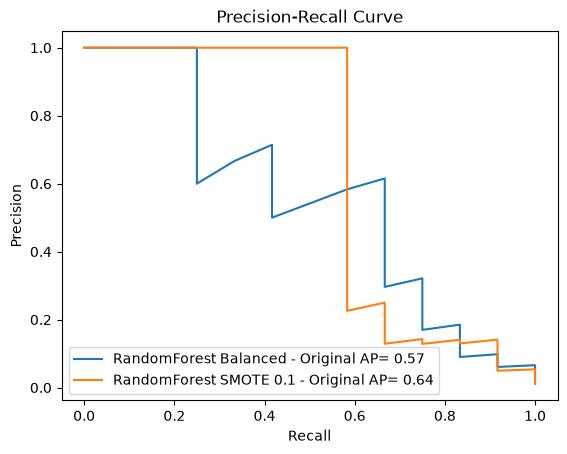

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [14]:
# Pipeline에 스케일링(및 SMOTE)이 포함되어 있으므로 원본 x_test를 사용
result_df = evaluate_models(model_dict, x_test, y_test, result_df)
result_df

RandomForest Balanced - Original - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.100241
1,Injection_Time,0.065783
2,Max_Injection_Speed,0.063715
3,Max_Back_Pressure,0.059814
4,Max_Injection_Pressure,0.056960
5,Mold_Temperature_4,0.056770
6,Plasticizing_Time,0.053636
7,Filling_Time,0.050373
8,Mold_Temperature_3,0.049267
9,Part_RG3LH,0.049043


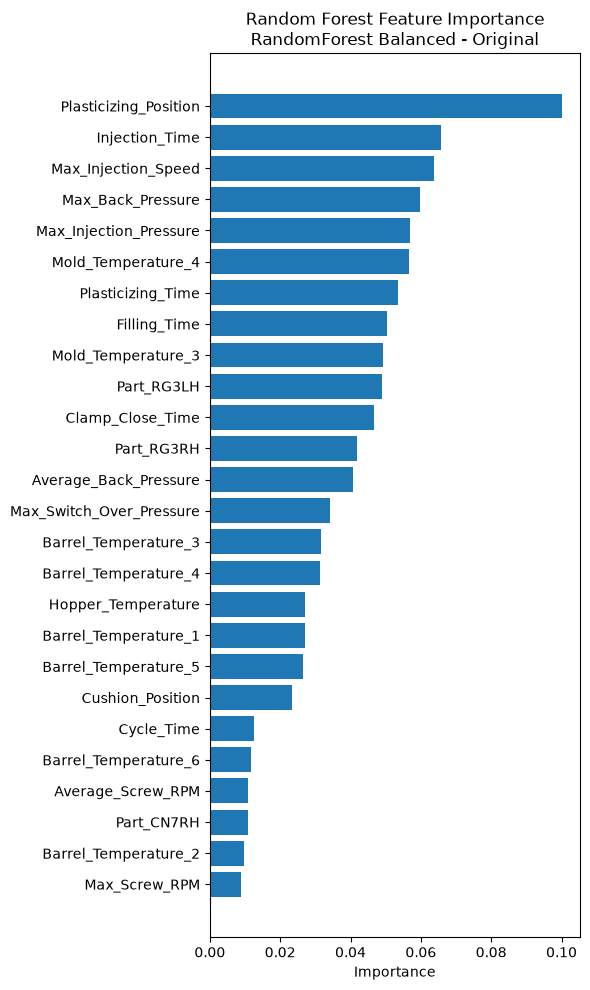

RandomForest SMOTE 0.1 - Original - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.075621
1,Max_Injection_Speed,0.070955
2,Clamp_Close_Time,0.061336
3,Max_Injection_Pressure,0.058222
4,Part_RG3RH,0.057092
5,Average_Screw_RPM,0.054769
6,Mold_Temperature_3,0.052970
7,Barrel_Temperature_5,0.049142
8,Filling_Time,0.046610
9,Mold_Temperature_4,0.043578


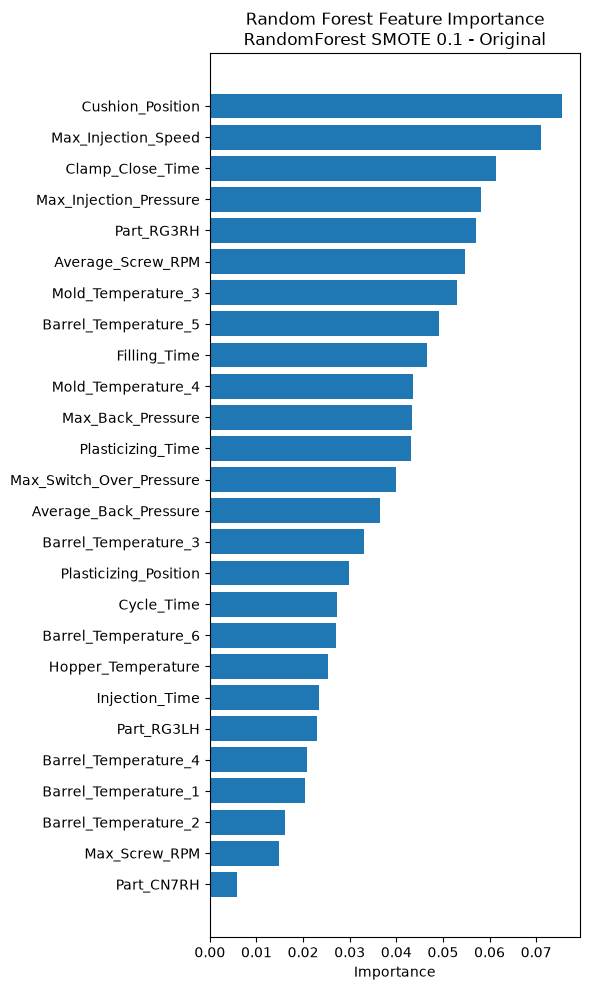

In [15]:
# Pipeline 안의 Random Forest만 꺼내서 중요도 출력
importance_tables = show_random_forest_feature_importance({name: model.named_steps['rf'] for name, model in model_dict.items()}, x_train.columns)

### Mutual Information 선택

#### 선택 특성

In [16]:
# GridSearchCV(refit=...)이므로 best_estimator_는 x_train 전체로 이미 학습된 상태
selection_summary_rows=[]
selected_feature_reports={}

for model_family in model_families:
    search=feature_searches[model_family]
    selector=search.best_estimator_.named_steps['selector']
    selection_summary_rows.append(
        {
            "Model Family": model_family,
            "Requested K": search.best_params_['selector__k_process'],
            "Selected Process Features": selector.actual_k_process_,
            "Part Features Kept": len(selector.part_features_),
            "Total Selected Features": len(selector.selected_features_),
            "Near-zero Removed": len(selector.near_zero_variance_features_),
            "High-correlation Removed": len(selector.correlation_dropped_features_)
        }
    )
    report=selector.selection_report()
    report.insert(0, 'Model Family', model_family)
    selected_feature_reports[model_family]=report

selection_summary_df=pd.DataFrame(selection_summary_rows)
selection_summary_df

,Model Family,Requested K,Selected Process Features,Part Features Kept,Total Selected Features,Near-zero Removed,High-correlation Removed
0,RandomForest Balanced,7,7,3,10,0,16
1,RandomForest SMOTE 0.1,7,7,3,10,0,16


In [17]:
# 선택된 공정 변수와 Mutual Information 점수
selected_features_detail=pd.concat(selected_feature_reports.values(), ignore_index=True)
selected_features_detail[selected_features_detail['Selected']].sort_values(
    ['Model Family', 'Mutual Information'],
    ascending=[True, False],
    ignore_index=True
).round(4)

,Model Family,Feature,Mutual Information,Selected
0,RandomForest Balanced,Max_Injection_Pressure,0.0160,True
1,RandomForest Balanced,Injection_Time,0.0130,True
2,RandomForest Balanced,Max_Back_Pressure,0.0105,True
3,RandomForest Balanced,Mold_Temperature_3,0.0078,True
4,RandomForest Balanced,Barrel_Temperature_4,0.0029,True
5,RandomForest Balanced,Max_Screw_RPM,0.0027,True
6,RandomForest Balanced,Hopper_Temperature,0.0025,True
7,RandomForest SMOTE 0.1,Max_Injection_Pressure,0.0160,True
8,RandomForest SMOTE 0.1,Injection_Time,0.0130,True
9,RandomForest SMOTE 0.1,Max_Back_Pressure,0.0105,True


#### 모델 학습

In [18]:
# 학습 모델 저장
model_dict={}

for model_family in model_families:
    model_dict[f'{model_family} - Feature Selected']=feature_searches[model_family].best_estimator_

#### 예측

RandomForest Balanced - Feature Selected
Accuracy: 0.9598470363288719
Average Precision: 0.30174211938728046
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.96      0.98      1034
          불량       0.17      0.67      0.28        12

    accuracy                           0.96      1046
   macro avg       0.58      0.81      0.63      1046
weighted avg       0.99      0.96      0.97      1046



RandomForest SMOTE 0.1 - Feature Selected
Accuracy: 0.9923518164435946
Average Precision: 0.6376318983191401
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.70      0.58      0.64        12

    accuracy                           0.99      1046
   macro avg       0.85      0.79      0.82      1046
weighted avg       0.99      0.99      0.99      1046



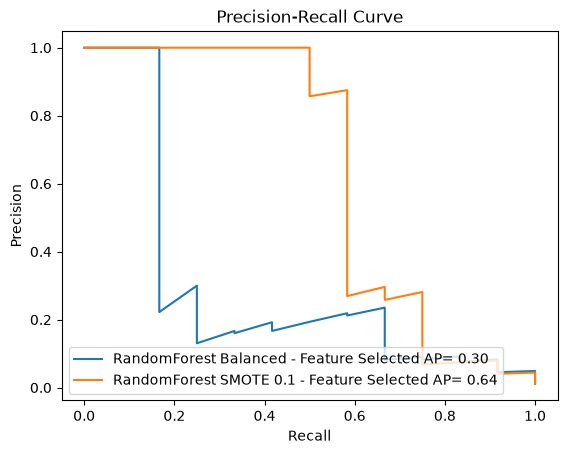

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [19]:
result_df = evaluate_models(model_dict, x_test, y_test, result_df)
result_df

RandomForest Balanced - Feature Selected - Random Forest Feature Importance


,Feature,Importance
0,Mold_Temperature_3,0.186807
1,Injection_Time,0.155811
2,Max_Back_Pressure,0.151806
3,Max_Injection_Pressure,0.147603
4,Hopper_Temperature,0.097358
5,Barrel_Temperature_4,0.093706
6,Part_RG3RH,0.055334
7,Part_RG3LH,0.045190
8,Max_Screw_RPM,0.037736
9,Part_CN7RH,0.028650


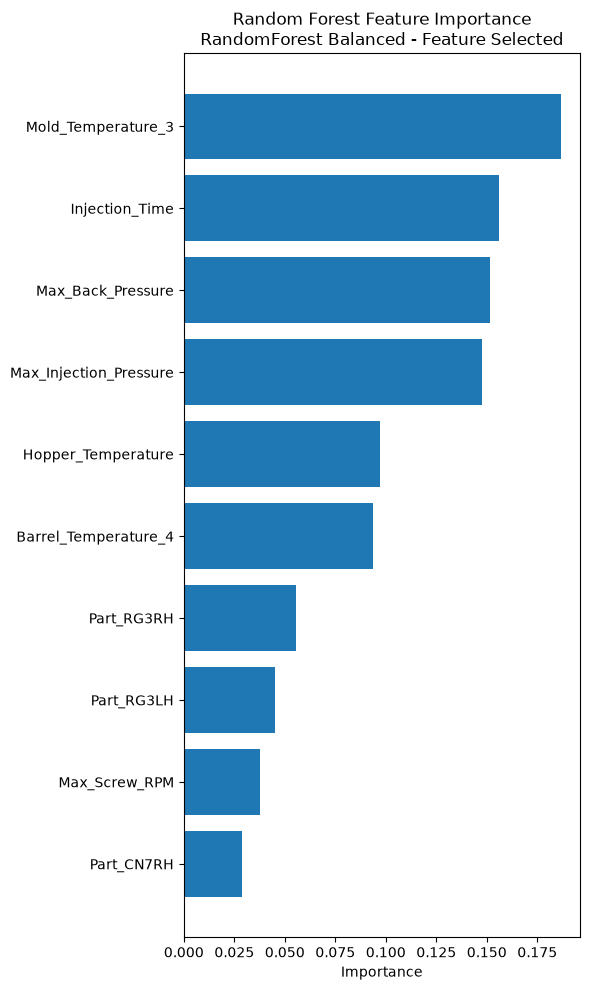

RandomForest SMOTE 0.1 - Feature Selected - Random Forest Feature Importance


,Feature,Importance
0,Max_Injection_Pressure,0.210379
1,Mold_Temperature_3,0.169311
2,Max_Back_Pressure,0.151291
3,Injection_Time,0.098558
4,Hopper_Temperature,0.096678
5,Barrel_Temperature_4,0.084554
6,Part_RG3RH,0.076997
7,Max_Screw_RPM,0.071388
8,Part_RG3LH,0.025550
9,Part_CN7RH,0.015294


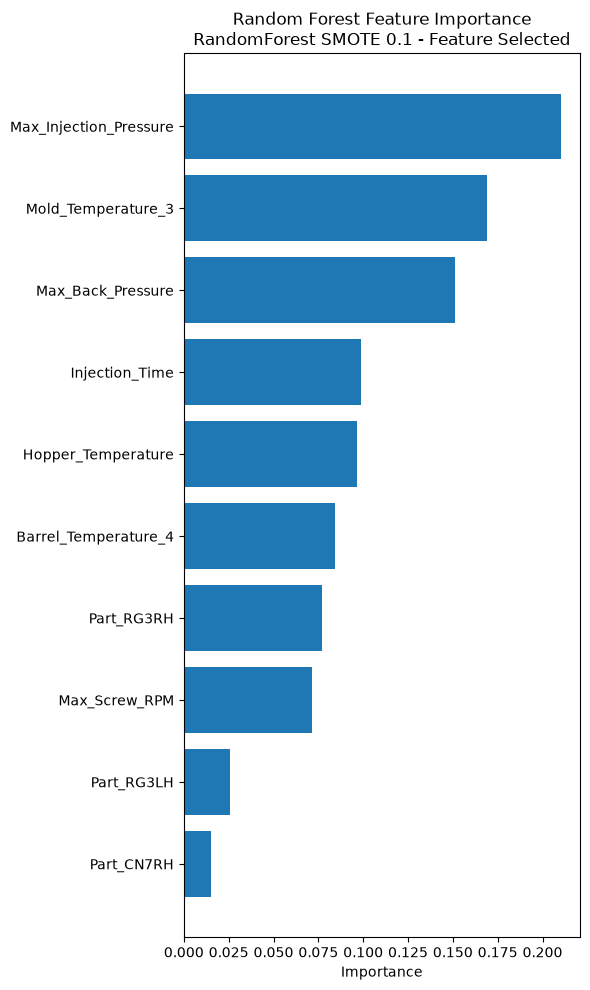

In [20]:
# 모델별로 선택된 특성이 다르므로 하나씩 중요도 출력
for model_name, model in model_dict.items():
    selected_features=model.named_steps['selector'].selected_features_
    importance_tables = show_random_forest_feature_importance({model_name: model.named_steps['rf']}, selected_features)

# 모델링 결과 요약

In [21]:
feature_model_names=[f'{model_family} - {strategy}' for model_family in model_families for strategy in ['Original', 'Feature Selected']]

result_df[result_df['Model'].isin(feature_model_names)].sort_values(['Average Precision', 'Defect Recall', 'Defect F1 Score'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
32,RandomForest SMOTE 0.1 - Original,0.777778,0.583333,0.666667,0.644045
34,RandomForest SMOTE 0.1 - Feature Selected,0.700000,0.583333,0.636364,0.637632
31,RandomForest Balanced - Original,0.296296,0.666667,0.410256,0.569480
33,RandomForest Balanced - Feature Selected,0.173913,0.666667,0.275862,0.301742


In [22]:
# 원본 특성 대비 변화량
compare_df=result_df[result_df['Model'].isin(feature_model_names)].drop_duplicates('Model', keep='last').set_index('Model')
metrics=['Defect Precision', 'Defect Recall', 'Defect F1 Score', 'Average Precision']

delta_rows=[]
for model_family in model_families:
    original=compare_df.loc[f'{model_family} - Original', metrics]
    selected=compare_df.loc[f'{model_family} - Feature Selected', metrics]
    delta=selected-original
    delta_rows.append({"Model Family": model_family, **{f'{metric} Delta': delta[metric] for metric in metrics}})

delta_df=pd.DataFrame(delta_rows)
delta_df.round(4)

,Model Family,Defect Precision Delta,Defect Recall Delta,Defect F1 Score Delta,Average Precision Delta
0,RandomForest Balanced,-0.1224,0.0,-0.1344,-0.2677
1,RandomForest SMOTE 0.1,-0.0778,0.0,-0.0303,-0.0064


In [23]:
result_df.sort_values(['Defect Recall', 'Defect F1 Score', 'Average Precision'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
12,RandomForest PART_NAME + Balanced,0.500000,0.666667,0.571429,0.596913
31,RandomForest Balanced - Original,0.296296,0.666667,0.410256,0.569480
19,RandomForest PART_NAME + Balanced GridSearch,0.296296,0.666667,0.410256,0.569480
22,Balanced RF - Original,0.296296,0.666667,0.410256,0.569480
33,RandomForest Balanced - Feature Selected,0.173913,0.666667,0.275862,0.301742
23,SMOTE RF - Original,0.777778,0.583333,0.666667,0.644045
32,RandomForest SMOTE 0.1 - Original,0.777778,0.583333,0.666667,0.644045
34,RandomForest SMOTE 0.1 - Feature Selected,0.700000,0.583333,0.636364,0.637632
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.700000,0.583333,0.636364,0.627161
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.583333,0.583333,0.583333,0.648783


In [24]:
result_df.to_csv('04_4_Feature_Selection.csv', index=False)

## 결과 요약

**선택 파이프라인 규모**
- 원본 26개 변수 → 근분산 0 제거 **0개** → 고상관(|r| > 0.95) 제거 **16개** → MI 후보 공정 변수 **7개**
- 최종 선택: 공정 7개 + Part 더미 3개(항상 보존) = **10개 변수**
- 요청한 K 후보 `[8, 12, 16, 20]`이 모두 후보 수 7로 잘려 **실질 K 탐색은 이뤄지지 않음** (상관 임계 0.95가 공격적이었음)

**선택된 변수와 Mutual Information**
| 변수 | MI |
|---|---|
| `Max_Injection_Pressure` | 0.0160 |
| `Injection_Time` | 0.0130 |
| `Max_Back_Pressure` | 0.0105 |
| `Mold_Temperature_3` | 0.0078 |
| `Barrel_Temperature_4` | 0.0029 |
| `Max_Screw_RPM` | 0.0027 |
| `Hopper_Temperature` | 0.0025 |

- MI는 라벨 기준으로만 계산되므로 두 모델 계열의 선택 결과가 **동일**함
- MI 최댓값이 0.016 수준 = **개별 변수 단독으로는 불량을 거의 설명하지 못함** → 신호가 변수 조합에 있음
- 04_3 PCA의 PC1~PC3 상위 기여 변수(사출 압력 · 사출 시간 · 배압 · 금형 온도)와 **겹침**

**교차검증 (train 5-fold)**
| 모델 계열 | 전략 | Mean AP | Mean Precision | Mean Recall | Mean F2 |
|---|---|---|---|---|---|
| RF Balanced | Original | **0.2954** ±0.089 | 0.2117 | 0.3533 | 0.3105 |
| RF Balanced | MI Top 7 + Part | 0.2220 ±0.092 | 0.1200 | 0.3933 | 0.2693 |
| RF SMOTE 0.1 | Original | **0.2562** ±0.076 | 0.6500 | 0.1667 | 0.1950 |
| RF SMOTE 0.1 | MI Top 7 + Part | 0.2175 ±0.078 | 0.4050 | 0.1444 | 0.1631 |

- 두 계열 모두 **원본이 선택본보다 AP가 높음**
- Balanced + MI7은 Recall이 소폭 올랐으나(0.353 → 0.393) Precision 제약 0.20을 **충족하지 못함**(0.120)이고 Recall 표준편차도 2배 이상 커짐(0.045 → 0.108)
- `Selected by CV`가 선택본으로 표시된 것은 **K 후보가 7 하나뿐**이라 자동 선택된 결과이며, 원본과의 우열 판정이 아님

**Test 성능 (1046건 / 불량 12건)**
| 모델 | Defect Precision | Defect Recall | Defect F1 | Average Precision |
|---|---|---|---|---|
| RF SMOTE 0.1 - Original | 0.778 | 0.583 | 0.667 | **0.644** |
| RF SMOTE 0.1 - Feature Selected | 0.700 | 0.583 | 0.636 | 0.638 |
| RF Balanced - Original | 0.296 | 0.667 | 0.410 | 0.569 |
| RF Balanced - Feature Selected | 0.174 | 0.667 | 0.276 | 0.302 |

- **SMOTE 계열: 변수를 26 → 10으로 줄여도 사실상 동등함** (AP -0.006, Recall 동일, Precision -0.078)
- **Balanced 계열: 크게 손실됨** (AP -0.268, F1 -0.134) — Recall은 유지되나 오탐이 급증
- 두 계열 모두 Recall 변화 0 = 놓치던 불량을 새로 잡아주지는 못함

**해석**
- 04_3 PCA(AP -0.44 ~ -0.60)와 달리 **정보 손실이 훨씬 작음** → 변수를 **선형 결합**하는 것보다 **원본 축을 유지한 채 개수만 줄이는 쪽**이 트리 모델에 적합함
- 그럼에도 성능이 오르지 않은 것은, 제거된 16개 고상관 변수가 **완전한 중복이 아니라 약한 보완 신호**를 갖고 있었기 때문임
- RandomForest는 분할 단계에서 이미 무관 변수를 걸러내므로, **26개 규모에서는 사전 변수 선택의 이득이 거의 없음**

**결론**
- **Feature Selection 미채택.** 원본 26개 변수 체계를 그대로 유지
- 다만 SMOTE 계열은 10개 변수로도 동등하므로, **운영 단계 경량화(센서 축소 · 추론 비용)** 근거로는 활용 가능
- 차원 축소 · 변수 선택 모두 이득이 없었으므로, 다음은 **비선형 재구성 기반 접근**으로 넘어감 (→ 04_5 AutoEncoder)
- 위 수치는 단일 분할(`random_state=0`) 기준 **후보 비교용**이며, 확정 수치는 04_6 반복 CV 결과를 따름
